# **Visualizing the History of Nobel Prize Winners**

The Nobel Prize has been among the most prestigious international awards since 1901. Each year, awards are bestowed in chemistry, literature, physics, physiology or medicine, economics, and peace. In addition to the honor, prestige, and substantial prize money, recipients also receive a gold medal featuring an image of Alfred Nobel (1833–1896), who established the prize.

For this project, I used the dataset made available by the Nobel Foundation, which contains records of all prize winners from the inception of the awards in 1901 through 2023. The dataset was sourced from the Nobel Prize API in the nobel.csv file.

In this project, I explored and answered several questions related to this prize-winning data, and investigated additional patterns and insights that sparked my interest.

Project Goals and Analytical Approach

In this project, I analyzed Nobel Prize winner data to uncover historical patterns across gender, nationality, decades, and award categories. I focused on answering specific research questions using data cleaning, grouping, and aggregation techniques.

I identified the most commonly awarded gender and birth country and stored the results in top_gender and top_country. I then calculated which decade had the highest proportion of US-born winners and saved it as max_decade_usa.

Next, I determined which decade and category had the highest share of female laureates, storing the result in max_female_dict. I also identified the first woman to receive the Nobel Prize and recorded her name and category in first_woman_name and first_woman_category.

Finally, I analyzed repeat winners and stored the names of individuals or organizations that won more than once in repeat_list.

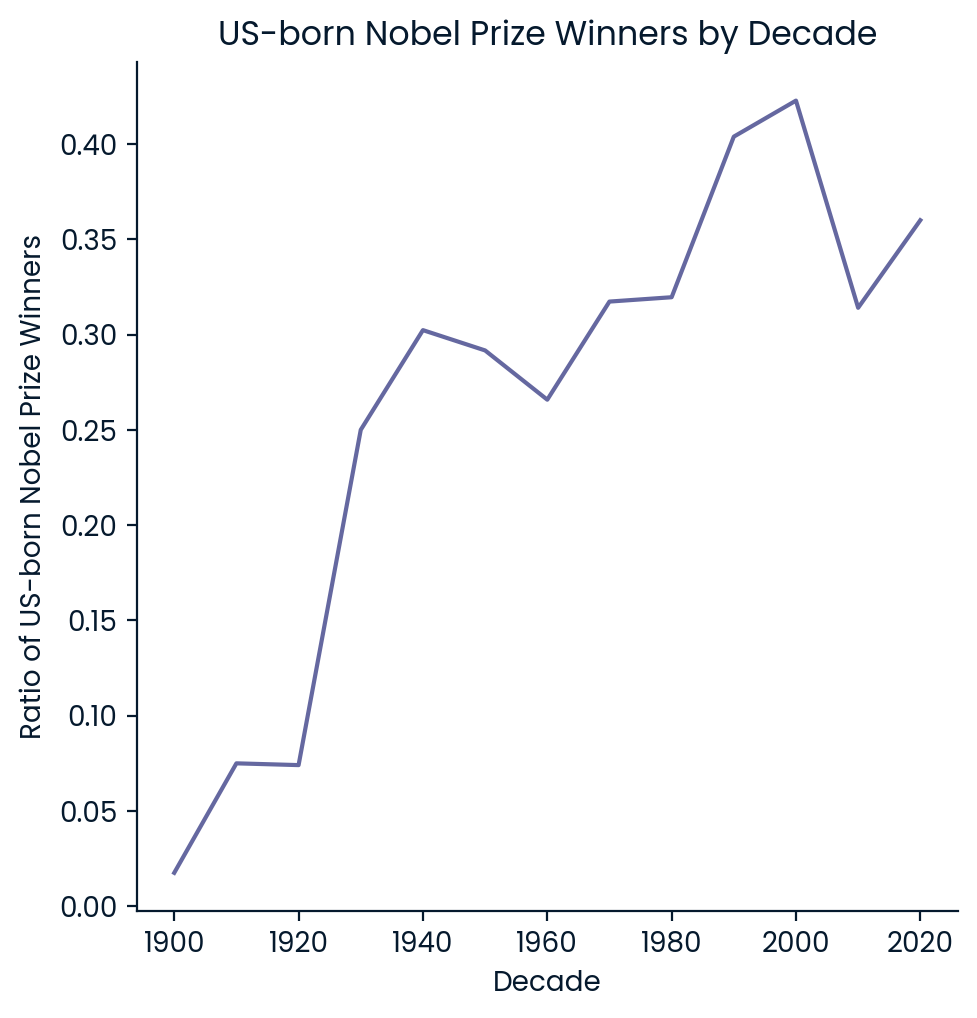

['Comité international de la Croix Rouge (International Committee of the Red Cross)',
 'Linus Carl Pauling',
 'John Bardeen',
 'Frederick Sanger',
 'Marie Curie, née Sklodowska',
 'Office of the United Nations High Commissioner for Refugees (UNHCR)']

In [ ]:
# Loading in required libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Loading the dataset
nobel = pd.read_csv("data/nobel.csv")
nobel.head()

# Most commonly awarded gender
top_gender = nobel["sex"].value_counts().index[0]
# Most commonly awarded birth country
top_country = nobel["birth_country"].value_counts().index[0]

top_gender, top_country

# Flaging US-born winners
nobel['US_born_winner'] = nobel['birth_country'] == 'United States of America'

# Created decade column
nobel['decade'] = (np.floor(nobel['year'] / 10) * 10).astype(int)

# Group by decade and calculated ratio of US-born winners
decade_ratio = (
    nobel
    .groupby('decade', as_index=False)['US_born_winner']
    .mean()  # mean gives the ratio since True=1, False=0
)

# Filtering for the row with the maximum US-born winner ratio
max_decade_usa = decade_ratio[decade_ratio['US_born_winner'] == decade_ratio['US_born_winner'].max()]['decade'].values[0]

max_decade_usa

# Line plot of US-born winner ratio by decade
sns.relplot(
    data=decade_ratio,        # DataFrame
    x='decade',               # X-axis
    y='US_born_winner',       # Y-axis (ratio)
    kind='line'               # Line plot
)

#  adding labels and title
plt.xlabel("Decade")
plt.ylabel("Ratio of US-born Nobel Prize Winners")
plt.title("US-born Nobel Prize Winners by Decade")
plt.show()

# Flaging female winners
nobel['female_winner'] = nobel['sex'] == 'Female'

# Created decade column if not already present
nobel['decade'] = (np.floor(nobel['year'] / 10) * 10).astype(int)

# Grouped by decade and category, calculated mean of female winners
female_ratio = (
    nobel
    .groupby(['decade', 'category'], as_index=False)['female_winner']
    .mean()
)

# Finding the row with the highest female winner ratio
max_female_row = female_ratio[female_ratio['female_winner'] == female_ratio['female_winner'].max()]

# Created a dictionary {decade: category}
max_female_dict = {max_female_row['decade'].values[0]: max_female_row['category'].values[0]}

max_female_dict

# Filtering for female winners
female_winners = nobel[nobel['female_winner']]

# Finding the row where the year is the minimum
first_female_row = female_winners[female_winners['year'] == female_winners['year'].min()]

# Extracting the name and category as strings
first_woman_name = first_female_row['full_name'].values[0]
first_woman_category = first_female_row['category'].values[0]
first_woman_name, first_woman_category

# Counting the occurrences of each winner
winner_counts = nobel['full_name'].value_counts()

# Keeping only those with 2 or more prizes
repeat_winners = winner_counts[winner_counts >= 2].index

# Converting to a list
repeat_list = list(repeat_winners)

repeat_list

